--- Model Evaluation ---
R² Score : 0.6913
MAE      : 100.5041
RMSE     : 129.1762


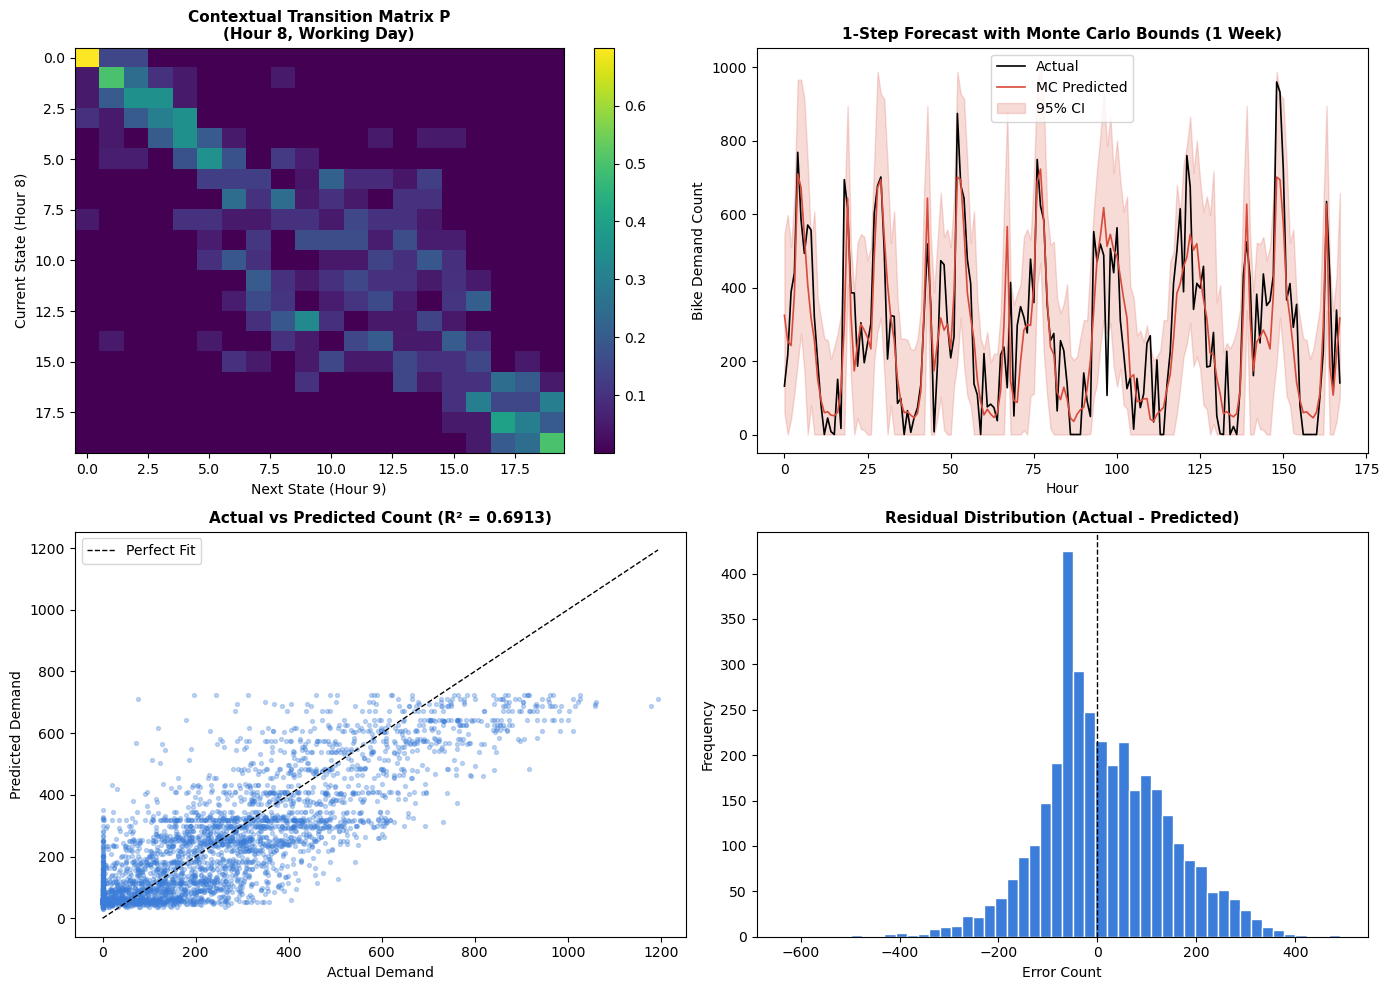

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seed for reproducibility
np.random.seed(42)

# 1. Load Dataset & Train/Test Chronological Split (80/20)
df = pd.read_csv("C:\\Users\\Priyansh yadav\\Downloads\\markov_bike_student_dataset.csv")

split = int(len(df) * 0.8)
train = df.iloc[:split].copy().reset_index(drop=True)
test = df.iloc[split:].copy().reset_index(drop=True)

# 2. Define Contexts & Quantile State Discretization (Fit on Train)
N_STATES = 20
train["ctx"] = list(zip(train["hr"], train["workingday"]))
test["ctx"] = list(zip(test["hr"], test["workingday"]))

bin_edges = {}
for ctx, group in train.groupby("ctx"):
    vals = group["lag_1"].fillna(0).values
    edges = np.percentile(vals, np.linspace(0, 100, N_STATES + 1))
    edges = np.unique(edges)
    if len(edges) < 2:
        edges = np.array([0, vals.max() + 1])
    bin_edges[ctx] = edges


def map_to_state(row):
    ctx = row["ctx"]
    edges = bin_edges[ctx]
    s = np.digitize([row["lag_1"]], edges[:-1])[0] - 1
    return int(np.clip(s, 0, len(edges) - 2))


train["state"] = train.apply(map_to_state, axis=1)
test["state"] = test.apply(map_to_state, axis=1)

# 3. Build Contextual Transition Probability Matrices P(s_next | s_curr, context)
contexts = train["ctx"].unique()
counts = {c: np.zeros((N_STATES, N_STATES)) for c in contexts}

for i in range(len(train) - 1):
    c = train["ctx"].iloc[i]
    s1 = train["state"].iloc[i]
    s2 = train["state"].iloc[i + 1]
    if c in counts and s1 < N_STATES and s2 < N_STATES:
        counts[c][s1, s2] += 1

# Apply Laplace Smoothing and Normalize
P = {}
for c, mat in counts.items():
    smoothed = mat + 1e-6
    P[c] = smoothed / smoothed.sum(axis=1, keepdims=True)

# 4. Map Discrete States back to Continuous Rental Quantiles
state_samples = {}
for c in contexts:
    sub = train[train["ctx"] == c]
    for s in range(N_STATES):
        vals = sub.loc[sub["state"] == s, "next_hour_demand"].values
        state_samples[(c, s)] = vals if len(vals) > 0 else np.array([0.0])


# 5. Monte Carlo Sampling Function
def monte_carlo_predict(ctx, state, next_ctx, n_sim=1000, seed=42):
    rng = np.random.default_rng(seed)
    trans_p = P.get(ctx, np.ones((N_STATES, N_STATES)) / N_STATES)[state]

    sim_next_states = rng.choice(N_STATES, size=n_sim, p=trans_p)
    sim_counts = [
        rng.choice(state_samples.get((next_ctx, s), np.array([0.0])))
        for s in sim_next_states
    ]
    sim_counts = np.array(sim_counts)

    return {
        "mean": np.mean(sim_counts),
        "lower_95": np.percentile(sim_counts, 2.5),
        "upper_95": np.percentile(sim_counts, 97.5),
    }


# 6. Perform 1-Step-Ahead Forecasts on Test Data
results = []
for i in range(len(test) - 1):
    ctx = test["ctx"].iloc[i]
    state = test["state"].iloc[i]
    next_ctx = test["ctx"].iloc[i + 1]
    actual = test["next_hour_demand"].iloc[i + 1]

    pred = monte_carlo_predict(ctx, state, next_ctx, n_sim=1000)
    results.append(
        {
            "actual": actual,
            "pred": pred["mean"],
            "lower": pred["lower_95"],
            "upper": pred["upper_95"],
        }
    )

res_df = pd.DataFrame(results)

# 7. Print Model Performance Summary
r2 = r2_score(res_df["actual"], res_df["pred"])
mae = mean_absolute_error(res_df["actual"], res_df["pred"])
rmse = np.sqrt(mean_squared_error(res_df["actual"], res_df["pred"]))

print(f"--- Model Evaluation ---")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# 8. Generate Visualizations Panel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Transition Probability Matrix Heatmap
im = axes[0, 0].imshow(P[(8, 1)], cmap="viridis", aspect="auto")
axes[0, 0].set_title(
    "Contextual Transition Matrix P\n(Hour 8, Working Day)",
    fontsize=11,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Next State (Hour 9)")
axes[0, 0].set_ylabel("Current State (Hour 8)")
fig.colorbar(im, ax=axes[0, 0])

# Subplot 2: Actual vs Predicted Time Series with 95% CI
window = slice(0, 168)  # 1 week test sample
x = np.arange(168)
axes[0, 1].plot(
    x, res_df["actual"].iloc[window], label="Actual", color="black", lw=1.2
)
axes[0, 1].plot(
    x,
    res_df["pred"].iloc[window],
    label="MC Predicted",
    color="#d84b3b",
    lw=1.2,
)
axes[0, 1].fill_between(
    x,
    res_df["lower"].iloc[window],
    res_df["upper"].iloc[window],
    color="#d84b3b",
    alpha=0.2,
    label="95% CI",
)
axes[0, 1].set_title(
    "1-Step Forecast with Monte Carlo Bounds (1 Week)",
    fontsize=11,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Bike Demand Count")
axes[0, 1].legend()

# Subplot 3: Actual vs Predicted Scatter Plot
axes[1, 0].scatter(
    res_df["actual"], res_df["pred"], alpha=0.3, s=8, color="#3b7dd8"
)
lims = [0, max(res_df["actual"].max(), res_df["pred"].max())]
axes[1, 0].plot(lims, lims, "k--", lw=1, label="Perfect Fit")
axes[1, 0].set_title(
    f"Actual vs Predicted Count (R² = {r2:.4f})", fontsize=11, fontweight="bold"
)
axes[1, 0].set_xlabel("Actual Demand")
axes[1, 0].set_ylabel("Predicted Demand")
axes[1, 0].legend()

# Subplot 4: Residual Distribution Histogram
residuals = res_df["actual"] - res_df["pred"]
axes[1, 1].hist(residuals, bins=50, color="#3b7dd8", edgecolor="white")
axes[1, 1].axvline(0, color="black", linestyle="--", lw=1)
axes[1, 1].set_title(
    "Residual Distribution (Actual - Predicted)", fontsize=11, fontweight="bold"
)
axes[1, 1].set_xlabel("Error Count")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()